In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import joblib

In [162]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [163]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [164]:
df.drop(columns=['person_gender'], inplace=True)
df.drop_duplicates(inplace=True)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_education                45000 non-null  object 
 2   person_income                   45000 non-null  float64
 3   person_emp_exp                  45000 non-null  int64  
 4   person_home_ownership           45000 non-null  object 
 5   loan_amnt                       45000 non-null  float64
 6   loan_intent                     45000 non-null  object 
 7   loan_int_rate                   45000 non-null  float64
 8   loan_percent_income             45000 non-null  float64
 9   cb_person_cred_hist_length      45000 non-null  float64
 10  credit_score                    45000 non-null  int64  
 11  previous_loan_defaults_on_file  45000 non-null  object 
 12  loan_status                     

In [166]:
categorical_columns = selector(dtype_include=object)(df)

In [167]:
for c in categorical_columns:
  print(c, df[c].unique())

person_education ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file ['No' 'Yes']


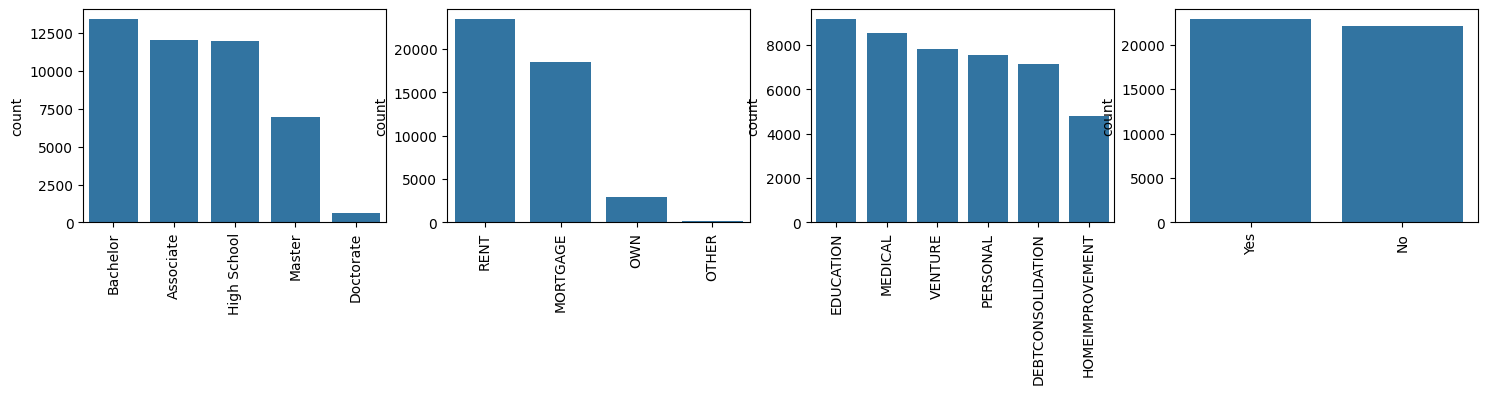

In [168]:
index = 1
plt.figure(figsize=(18,36))

for col in categorical_columns:
  y_axis = df[col].value_counts()
  plt.subplot(11,4,index)
  plt.xticks(rotation=90)
  sns.barplot(x=list(y_axis.index), y=y_axis)
  index +=1

In [169]:
numerical_columns = selector(dtype_exclude=object)(df.drop(columns=['loan_status']))
print(numerical_columns)

['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


In [170]:
# Identifying highly correlated features
numerical_columns_with_loan_status = selector(dtype_exclude=object)(df)

numerical_data = df[numerical_columns_with_loan_status]
corr_matrix = numerical_data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.9)]
print(high_corr_features)

['person_emp_exp']


In [171]:
corr_matrix['person_emp_exp'].sort_values(ascending=False)

person_emp_exp                1.000000
person_age                    0.954412
cb_person_cred_hist_length    0.824272
credit_score                  0.186196
person_income                 0.185987
loan_amnt                     0.044589
loan_percent_income           0.039862
loan_status                   0.020481
loan_int_rate                 0.016631
Name: person_emp_exp, dtype: float64

In [172]:
corr_with_target = numerical_data.corr()['loan_status'].sort_values(ascending=False)
print(corr_with_target)

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64


In [173]:
df.drop(columns=high_corr_features, inplace=True)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_education                45000 non-null  object 
 2   person_income                   45000 non-null  float64
 3   person_home_ownership           45000 non-null  object 
 4   loan_amnt                       45000 non-null  float64
 5   loan_intent                     45000 non-null  object 
 6   loan_int_rate                   45000 non-null  float64
 7   loan_percent_income             45000 non-null  float64
 8   cb_person_cred_hist_length      45000 non-null  float64
 9   credit_score                    45000 non-null  int64  
 10  previous_loan_defaults_on_file  45000 non-null  object 
 11  loan_status                     45000 non-null  int64  
dtypes: float64(6), int64(2), object(

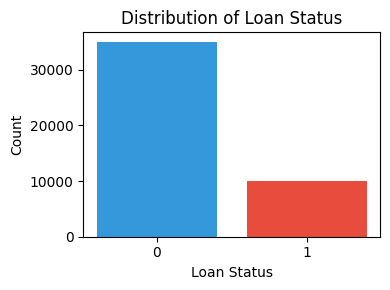

In [175]:
plt.figure(figsize=(4, 3))
counts = df['loan_status'].value_counts()
plt.bar(counts.index, counts.values, color=['#3498db', '#e74c3c'])
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

In [176]:
numerical_columns = selector(dtype_exclude=object)(df.drop(columns=['loan_status']))

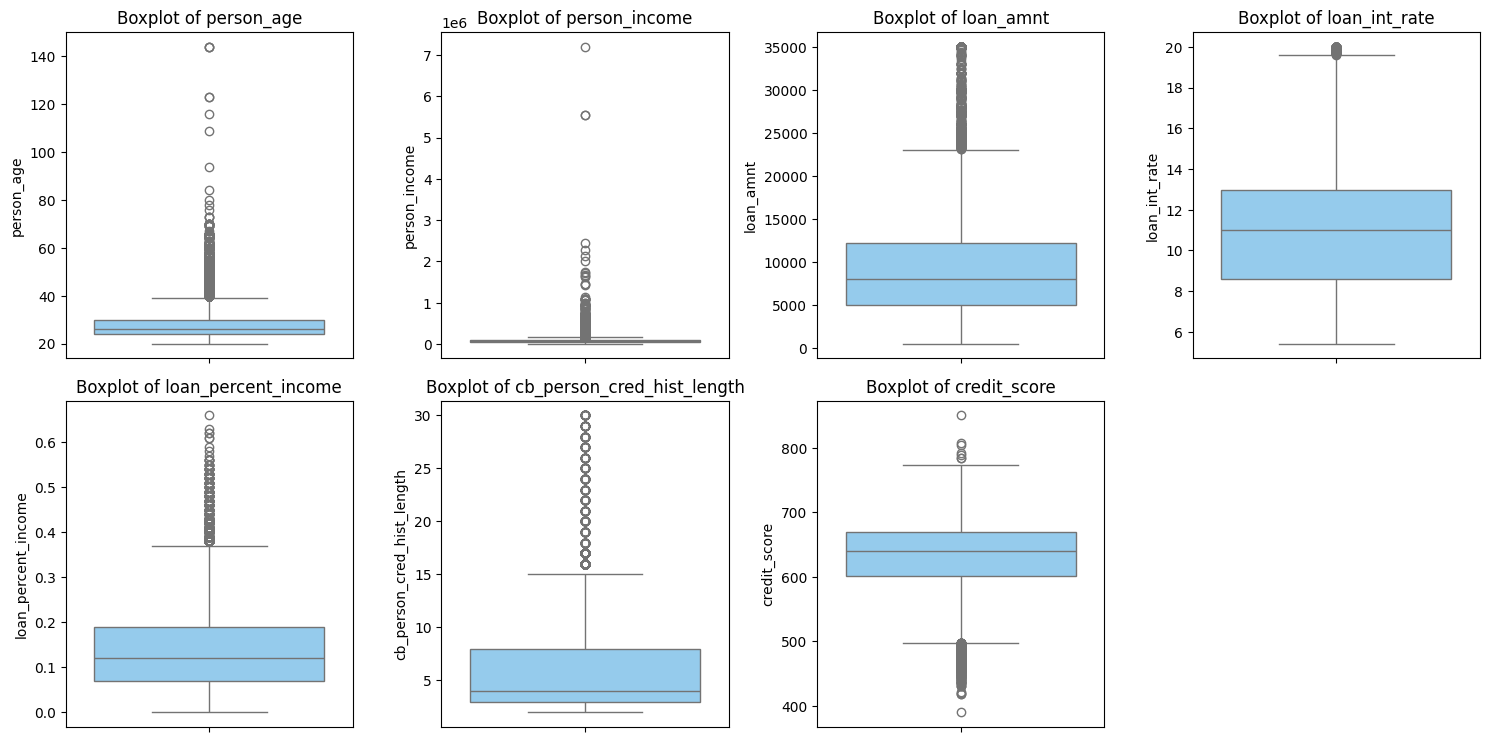

In [177]:
plt.figure(figsize=(15, 15))
for i, col in zip(range(1, len(numerical_columns)+1), numerical_columns):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightskyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [178]:
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 100)]
df = df[df['person_income'] > 0]
df = df[(df['loan_int_rate'] >= 0) & (df['loan_int_rate'] <= 100)]
df = df[(df['credit_score'] >= 300) & (df['credit_score'] <= 850)]

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44993 entries, 0 to 44999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_education                44993 non-null  object 
 2   person_income                   44993 non-null  float64
 3   person_home_ownership           44993 non-null  object 
 4   loan_amnt                       44993 non-null  float64
 5   loan_intent                     44993 non-null  object 
 6   loan_int_rate                   44993 non-null  float64
 7   loan_percent_income             44993 non-null  float64
 8   cb_person_cred_hist_length      44993 non-null  float64
 9   credit_score                    44993 non-null  int64  
 10  previous_loan_defaults_on_file  44993 non-null  object 
 11  loan_status                     44993 non-null  int64  
dtypes: float64(6), int64(2), object(4)
me

In [180]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [181]:
numerical_columns = selector(dtype_exclude=object)(X)

In [182]:
# Detecting which of the numerical columns have outlier
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((data < lower_bound) | (data > upper_bound)).any()

    return has_outliers

In [183]:
for n in numerical_columns:
  print(n, detect_outliers_iqr(df[n]))

person_age True
person_income True
loan_amnt True
loan_int_rate True
loan_percent_income True
cb_person_cred_hist_length True
credit_score True


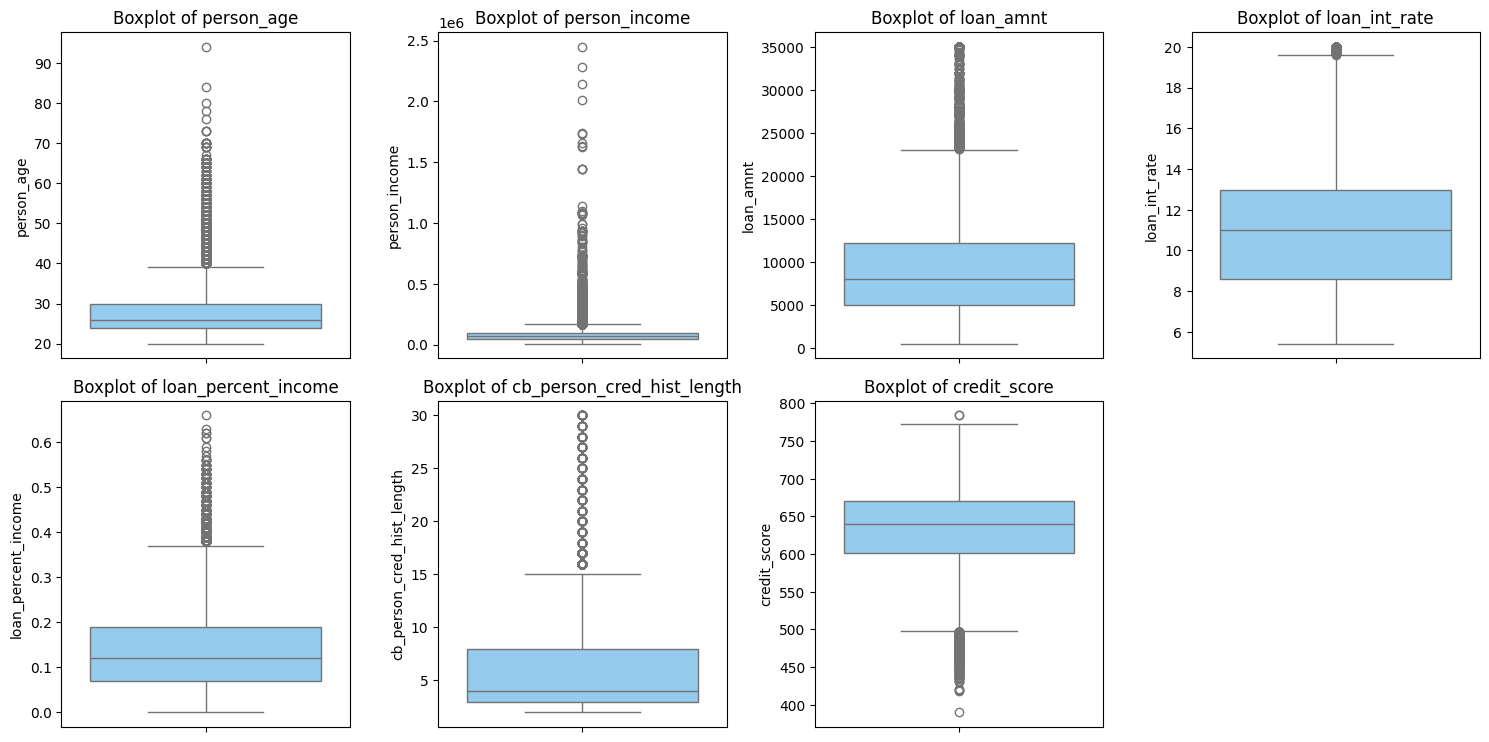

In [184]:
plt.figure(figsize=(15, 15))
for i, col in zip(range(1, len(numerical_columns)+1), numerical_columns):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightskyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [185]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [186]:
cat_without_order = ['person_home_ownership', 'loan_intent']
cat_with_order = ['previous_loan_defaults_on_file']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_columns),
        ('cat_without_order', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_without_order),
        ('cat_education', OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]), ['person_education']),
        ('cat_with_order', OrdinalEncoder(), cat_with_order)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [187]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
classifier.fit(X_train_processed, y_train)
y_pred = classifier.predict(X_test_processed)

accuracy_forest = accuracy_score(y_test, y_pred)
classification_report_forest = classification_report(y_test, y_pred)
confusion_matrix_forest = confusion_matrix(y_test, y_pred)
    
print('Accuracy:', accuracy_forest)
print('Classification Report:\n', classification_report_forest)
print('Confusion matrix:', confusion_matrix_forest)

Accuracy: 0.9307700855650628
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7002
           1       0.90      0.77      0.83      1997

    accuracy                           0.93      8999
   macro avg       0.92      0.87      0.89      8999
weighted avg       0.93      0.93      0.93      8999

Confusion matrix: [[6838  164]
 [ 459 1538]]


In [188]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_processed, y_train)
y_pred = lr.predict(X_test_processed)

accuracy_lr = accuracy_score(y_test, y_pred)
classification_report_lr = classification_report(y_test, y_pred)
confusion_matrix_lr = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_lr)
print("Classification Report:\n", classification_report_lr)
print("Confusion Matrix:\n", confusion_matrix_lr)

Accuracy: 0.8623180353372597
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.91      7002
           1       0.63      0.92      0.75      1997

    accuracy                           0.86      8999
   macro avg       0.80      0.88      0.83      8999
weighted avg       0.90      0.86      0.87      8999

Confusion Matrix:
 [[5915 1087]
 [ 152 1845]]


In [189]:
svc = svm.SVC(kernel='linear', C=1, class_weight='balanced')
svc.fit(X_train_processed, y_train)
y_pred = svc.predict(X_test_processed)

accuracy_linear = accuracy_score(y_test, y_pred)
classification_report_linear = classification_report(y_test, y_pred)
confusion_matrix_linear = confusion_matrix(y_test, y_pred)

print('Accuracy:', accuracy_linear)
print('Classification Report:\n', classification_report_linear)
print('Confusion matrix:\n', confusion_matrix_linear)

Accuracy: 0.8594288254250473
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90      7002
           1       0.62      0.93      0.75      1997

    accuracy                           0.86      8999
   macro avg       0.80      0.88      0.82      8999
weighted avg       0.90      0.86      0.87      8999

Confusion matrix:
 [[5880 1122]
 [ 143 1854]]


In [190]:
comparison_performance = {
    'Model': ['Logistic Regression', 'SVC', 'Random Forest Classifier'],
    'accuracy score': [accuracy_lr, accuracy_linear, accuracy_forest],
    'Classification report': [classification_report_lr, classification_report_linear, confusion_matrix_forest],
    'Confusion matrix': [confusion_matrix_lr, confusion_matrix_linear, confusion_matrix_forest]
}
comparison_df = pd.DataFrame(comparison_performance)
print('Comparison performance: \n')
print(comparison_df)

Comparison performance: 

                      Model  accuracy score  \
0       Logistic Regression        0.862318   
1                       SVC        0.859429   
2  Random Forest Classifier        0.930770   

                               Classification report  \
0                precision    recall  f1-score   ...   
1                precision    recall  f1-score   ...   
2                         [[6838, 164], [459, 1538]]   

              Confusion matrix  
0  [[5915, 1087], [152, 1845]]  
1  [[5880, 1122], [143, 1854]]  
2   [[6838, 164], [459, 1538]]  


In [191]:
def tune_model(model, param_grid):
    tuner = RandomizedSearchCV(model, param_grid, cv=5, n_iter=20, verbose=True, random_state=42, n_jobs=-1)
    tuner.fit(X_train_processed, y_train)
    print(f"Best score for: {model.__class__.__name__}: {tuner.best_score_:.2f}")
    print(f"Best parameters for: {model.__class__.__name__}: {tuner.best_params_}")
    return tuner.best_estimator_

In [192]:
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
lr_grid = {
    'C': np.logspace(-4, 4, 20), 
    'solver': ['liblinear']
}
svc_grid = {'C': [0.1, 0.5, 0.75, 1], "kernel": ['linear']}

In [193]:
best_rf_reg = tune_model(RandomForestClassifier(random_state=42), rf_grid)
best_lr_reg = tune_model(LogisticRegression(random_state=42), lr_grid)
best_svc_reg = tune_model(svm.SVC(random_state=42), svc_grid)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score for: RandomForestClassifier: 0.93
Best parameters for: RandomForestClassifier: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best score for: LogisticRegression: 0.90
Best parameters for: LogisticRegression: {'solver': 'liblinear', 'C': np.float64(0.03359818286283781)}
Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best score for: SVC: 0.90
Best parameters for: SVC: {'kernel': 'linear', 'C': 1}


In [194]:
cv_scores = cross_val_score(best_rf_reg, X_train_processed, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-Validation AUC Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-Validation AUC Scores: [0.97531758 0.97611978 0.97635354 0.9733236  0.97273362]
Mean CV AUC: 0.9748 (+/- 0.0029)


In [195]:
final_model = best_rf_reg

joblib.dump(final_model, 'loan_status_predictor.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [196]:
def predict_loan_status(applicant_data):
    model = joblib.load('loan_status_predictor.pkl')
    preprocessor = joblib.load('preprocessor.pkl')

    processed_data = preprocessor.transform(applicant_data)
    
    prediction = model.predict(processed_data)
    probabilities = model.predict_proba(processed_data)
    
    return {
        'status': prediction[0],
        'probability_approved': probabilities[0][1],
        'probability_rejected': probabilities[0][0]
    }

In [197]:
# Prediction system

new_applicant = pd.DataFrame({
    'person_age': [30],
    'person_income': [50000],
    'person_emp_exp': [5],
    'person_home_ownership': ['RENT'],
    'loan_intent': ['PERSONAL'],
    'loan_amnt': [10000],
    'loan_int_rate': [8.5],
    'loan_percent_income': [0.2],
    'credit_score': [700],
    'person_education': ['Bachelor'],
    'previous_loan_defaults_on_file': ['No'],
    'cb_person_cred_hist_length': [5.0]
})
# new_applicant = pd.DataFrame({
#     'person_age': [22.0], 
#     'person_education': ['Master'],
#     'person_income': [71948.0],
#     'person_emp_exp': [0],
#     'person_home_ownership': ['RENT'],
#     'loan_amnt': [35000.0],
#     'loan_intent': ['PERSONAL'],
#     'loan_int_rate': [16.02],
#     'loan_percent_income': [0.49],
#     'cb_person_cred_hist_length': [3.0],
#     'credit_score': [561],
#     'previous_loan_defaults_on_file': ['No']
# })

result = predict_loan_status(new_applicant)

result_status = 'Loan Approved' if result['status'] == 1 else 'Loan Not Approved'
print(f"Prediction result : {result_status}")
print(f"Approval probability : {result['probability_approved']:.2%}")
print(f"Denied probability : {result['probability_rejected']:.2%}")

Prediction result : Loan Not Approved
Approval probability : 8.37%
Denied probability : 91.63%
